<a href="https://colab.research.google.com/github/JozefSL/EIA/blob/main/hourlyNGgenerationTX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

excel_url = 'https://www.eia.gov/electricity/gridmonitor/knownissues/xls/Region_TEX.xlsx'

try:
    df = pd.read_excel(excel_url)
    print("Data imported successfully!")
    display(df.head())
except Exception as e:
    print(f"Error importing data: {e}")

Data imported successfully!


,Region,UTC time,Local date,Hour,Local time,Time zone,Demand forecast,Demand,Net generation,Total interchange,...,CO2 Emissions: OIL,CO2 Emissions: Other,CO2 Emissions Generated,CO2 Emissions Imported,CO2 Emissions Exported,CO2 Emissions Consumed,Positive Generation,Consumed Electricity,CO2 Emissions Intensity for Generated Electricity,CO2 Emissions Intensity for Consumed Electricity
0,TEX,2015-07-01 06:00:00,2015-07-01,1,2015-07-01 01:00:00,Central,39708.0,37456.0,37462.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TEX,2015-07-01 07:00:00,2015-07-01,2,2015-07-01 02:00:00,Central,37338.0,35119.0,35124.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TEX,2015-07-01 08:00:00,2015-07-01,3,2015-07-01 03:00:00,Central,35697.0,33638.0,33642.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TEX,2015-07-01 09:00:00,2015-07-01,4,2015-07-01 04:00:00,Central,34772.0,32798.0,32805.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEX,2015-07-01 10:00:00,2015-07-01,5,2015-07-01 05:00:00,Central,34773.0,32805.0,32812.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#df.info()

In [6]:
df['year'] = df['UTC time'].dt.year
df = df.sort_values(by=['Region', 'year', 'UTC time']).reset_index(drop=True)

df['NG_NG_hourly_diff'] = df.groupby(['Region', 'year'])['NG: NG'].diff()

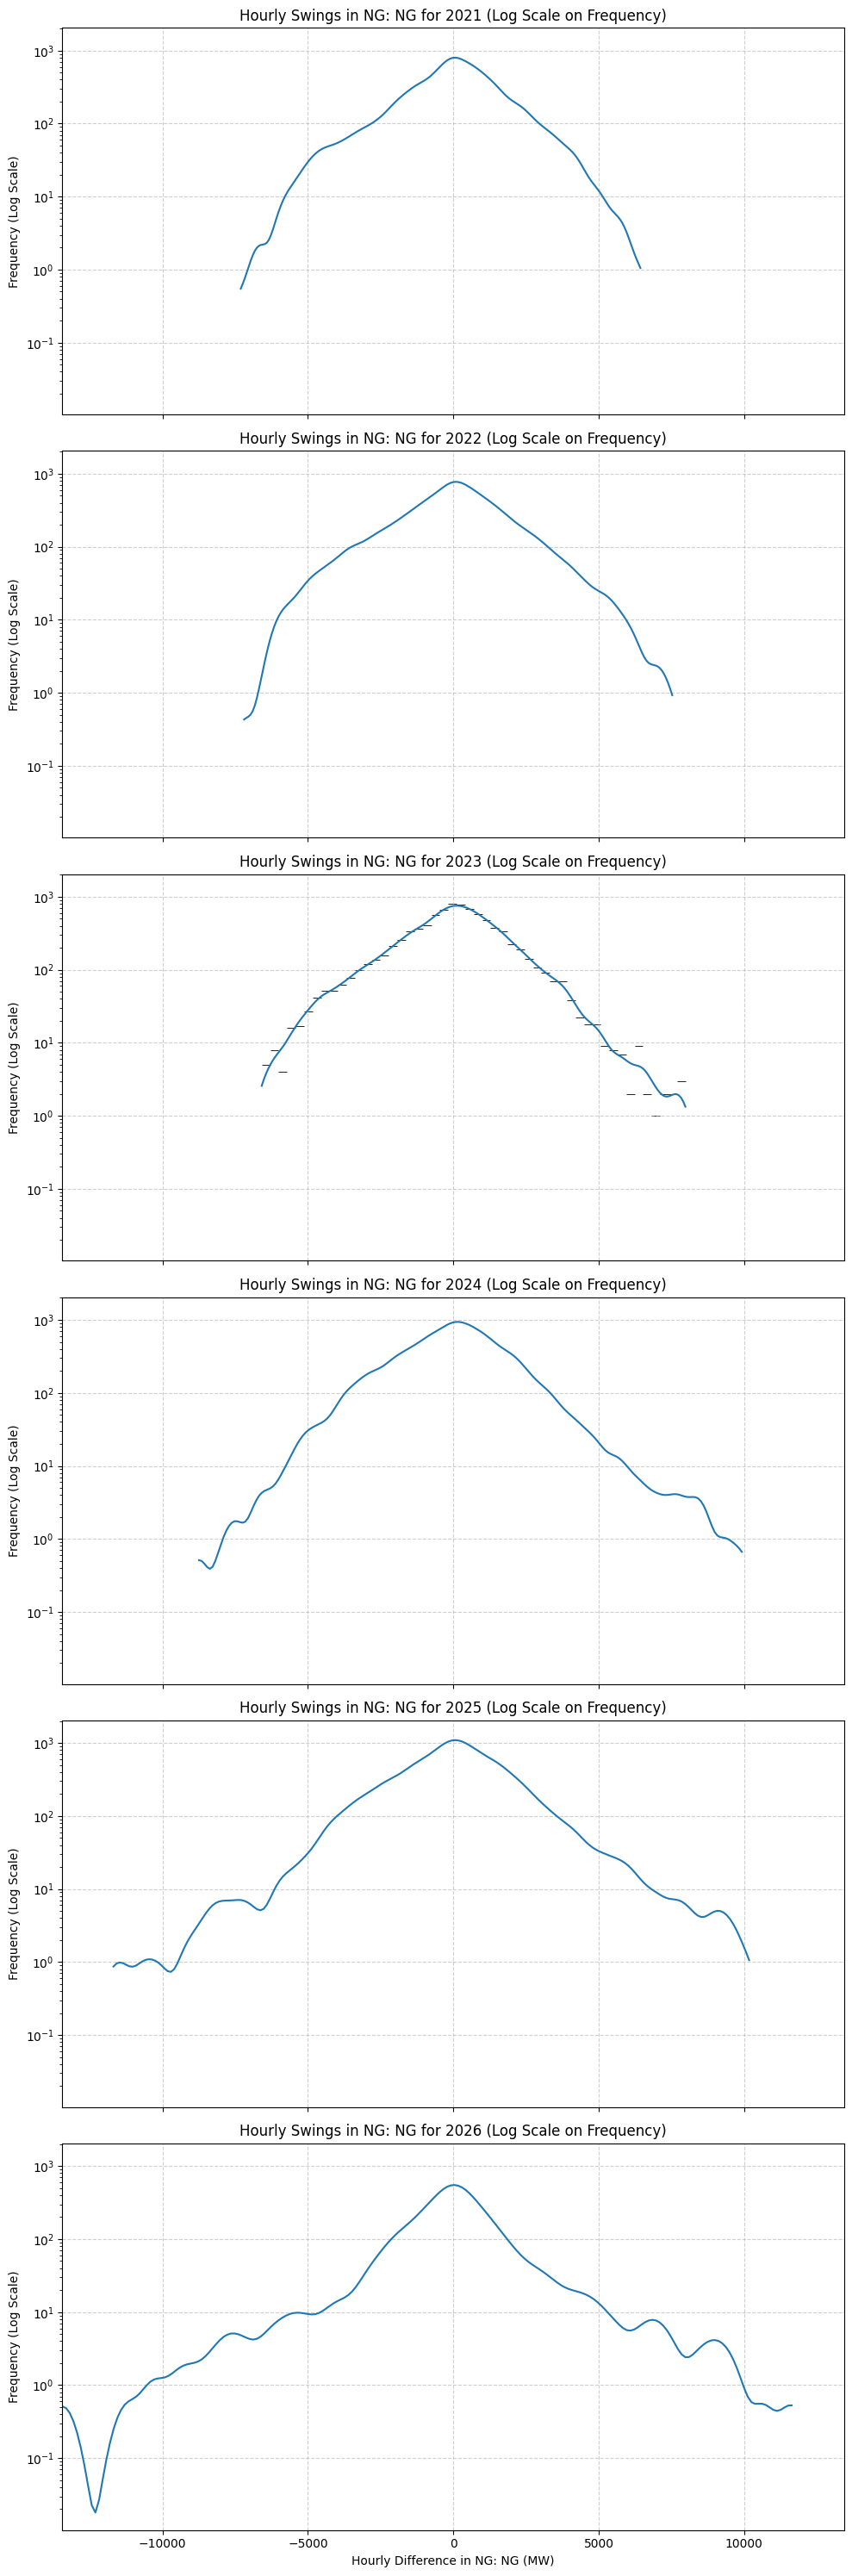

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for years 2021 and higher
df_filtered = df[df['year'] >= 2021]

# Get unique years for plotting from the filtered data
years = df_filtered['year'].unique()

# Calculate the maximum absolute difference for symmetric x-axis limits
max_abs_diff = df_filtered['NG_NG_hourly_diff'].abs().max()

# Create a figure and a set of subplots based on the number of years
# Set sharey=True to ensure all y-axes have the same scale
num_years = len(years)
fig, axes = plt.subplots(nrows=num_years, ncols=1, figsize=(10, 5 * num_years), sharex=True, sharey=True)

# If there's only one year, axes might not be an array, so make it one for consistent iteration
if num_years == 1:
    axes = [axes]

for i, year in enumerate(years):
    # Filter data for the current year from the filtered DataFrame
    year_data = df_filtered[df_filtered['year'] == year]

    # Plot histogram on the corresponding subplot with log scale for frequency only
    sns.histplot(year_data['NG_NG_hourly_diff'].dropna(), bins=50, kde=True, ax=axes[i], log_scale=(False, True))
    axes[i].set_title(f'Hourly Swings in NG: NG for {year} (Log Scale on Frequency)')
    axes[i].set_xlabel('Hourly Difference in NG: NG (MW)')
    axes[i].set_ylabel('Frequency (Log Scale)')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    # Set symmetric x-axis limits
    axes[i].set_xlim(-max_abs_diff, max_abs_diff)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

# Find the largest positive swing
max_swing_row = df_filtered.loc[df_filtered['NG_NG_hourly_diff'].idxmax()]
max_swing_value = max_swing_row['NG_NG_hourly_diff']
max_swing_time = max_swing_row['UTC time']

# Find the largest negative swing
min_swing_row = df_filtered.loc[df_filtered['NG_NG_hourly_diff'].idxmin()]
min_swing_value = min_swing_row['NG_NG_hourly_diff']
min_swing_time = min_swing_row['UTC time']

# Create a DataFrame to display the results
swing_data = {
    'Swing Type': ['Largest Positive Swing', 'Largest Negative Swing'],
    'Swing Value (MW)': [max_swing_value, min_swing_value],
    'UTC Time': [max_swing_time, min_swing_time]
}

swing_df = pd.DataFrame(swing_data)
display(swing_df)

,Swing Type,Swing Value (MW),UTC Time
0,Largest Positive Swing,11633.0,2026-02-01 00:00:00
1,Largest Negative Swing,-13441.0,2026-01-28 16:00:00


In [14]:
import pandas as pd

years = df_filtered['year'].unique()
annual_swings = []

for year in sorted(years):
    year_data = df_filtered[df_filtered['year'] == year]

    if not year_data.empty:
        # Largest Positive Swing for the year
        max_swing_row_year = year_data.loc[year_data['NG_NG_hourly_diff'].idxmax()]
        annual_swings.append({
            'Year': year,
            'Swing Type': 'Largest Positive Swing',
            'Swing Value (MW)': max_swing_row_year['NG_NG_hourly_diff'],
            'UTC Time': max_swing_row_year['UTC time']
        })

        # Largest Negative Swing for the year
        min_swing_row_year = year_data.loc[year_data['NG_NG_hourly_diff'].idxmin()]
        annual_swings.append({
            'Year': year,
            'Swing Type': 'Largest Negative Swing',
            'Swing Value (MW)': min_swing_row_year['NG_NG_hourly_diff'],
            'UTC Time': min_swing_row_year['UTC time']
        })

annual_swings_df = pd.DataFrame(annual_swings)
display(annual_swings_df)

,Year,Swing Type,Swing Value (MW),UTC Time
0,2021,Largest Positive Swing,6432.0,2021-09-04 17:00:00
1,2021,Largest Negative Swing,-7309.0,2021-02-15 09:00:00
2,2022,Largest Positive Swing,7527.0,2022-12-15 00:00:00
3,2022,Largest Negative Swing,-7196.0,2022-04-21 04:00:00
4,2023,Largest Positive Swing,7979.0,2023-12-30 00:00:00
5,2023,Largest Negative Swing,-6589.0,2023-05-09 04:00:00
6,2024,Largest Positive Swing,9918.0,2024-01-13 00:00:00
7,2024,Largest Negative Swing,-8746.0,2024-02-13 15:00:00
8,2025,Largest Positive Swing,10171.0,2025-01-20 00:00:00
9,2025,Largest Negative Swing,-11686.0,2025-12-31 16:00:00
